# 05_Multi_Presentation_Update_SER

Notebook này là bản update để thử tăng kết quả trên **strict / speaker-aware generalization**.

Ý tưởng chính:

1. **Deeper train-only augmentation**: waveform-level pitch shift, time stretch, additive noise, random gain, raw time shift, light reverb/time masking, plus feature-level masking and mixup.
2. **Richer statistical features**: thêm nhiều thống kê như median, percentile, IQR, range, skewness, kurtosis, pitch/F0 proxy.
3. **Temporal BiLSTM branch**: thay BiGRU bằng BiLSTM để học ngữ cảnh hai chiều trên chuỗi acoustic feature.
4. **Pretrained speech embedding branch**: dùng wav2vec2/WavLM-style speech representation ở chế độ frozen feature extractor, không fine-tune.
5. **Stacking ensemble**: dùng validation probabilities của các branch để train meta-classifier, thay vì chỉ weighted average.

Mục tiêu của bản này không phải thay toàn bộ kết quả cũ, mà là tạo một hướng thử nghiệm mạnh hơn cho strict split và hướng tới hệ thống feedback thực tế.


## 1. Imports

Notebook ưu tiên chạy được trên Kaggle/Colab. Nếu `transformers` hoặc checkpoint pretrained không tải được, pretrained speech branch sẽ tự skip và các branch còn lại vẫn chạy.


In [1]:
import os
import json
import time
import random
import shutil
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import librosa
import soundfile as sf

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.feature_selection import VarianceThreshold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix,
)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

SEED = int(os.getenv("SEED", "42"))
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
GPU_COUNT = torch.cuda.device_count() if torch.cuda.is_available() else 0
USE_MULTI_GPU = os.getenv("USE_MULTI_GPU", "1") == "1"
torch.backends.cudnn.benchmark = False


def maybe_data_parallel(model, name="model"):
    if USE_MULTI_GPU and GPU_COUNT > 1:
        print(f"Using DataParallel for {name} on {GPU_COUNT} GPUs")
        return nn.DataParallel(model)
    return model


print("Device:", DEVICE)
print("GPU_COUNT:", GPU_COUNT, "USE_MULTI_GPU:", USE_MULTI_GPU)


Device: cuda
GPU_COUNT: 2 USE_MULTI_GPU: True


## 2. Configuration

Các biến môi trường có thể chỉnh trên Kaggle trước khi chạy:

```text
QUICK_RUN=1                    # kiểm tra pipeline nhanh
USE_MULTI_GPU=1                # tự dùng DataParallel nếu Kaggle có 2 GPU
RUN_PRETRAINED_SPEECH=0         # tắt pretrained branch nếu Kaggle không có internet
PRETRAINED_SPEECH_MODEL=microsoft/wavlm-base-plus
MAX_EPOCHS=35
ENABLE_RICH_PITCH=1
```


In [2]:
QUICK_RUN = os.getenv("QUICK_RUN", "0") == "1"
QUICK_RUN_PER_GROUP = int(os.getenv("QUICK_RUN_PER_GROUP", "18"))

TARGET_SR = 16_000
TARGET_DURATION = float(os.getenv("TARGET_DURATION", "3.0"))
TARGET_LENGTH = int(TARGET_SR * TARGET_DURATION)
N_FFT = int(os.getenv("N_FFT", "400"))
WIN_LENGTH = int(os.getenv("WIN_LENGTH", "400"))
HOP_LENGTH = int(os.getenv("HOP_LENGTH", "160"))
N_MFCC = int(os.getenv("N_MFCC", "40"))
N_MELS = int(os.getenv("N_MELS", "96"))
MAX_FRAMES = int(1 + TARGET_LENGTH // HOP_LENGTH)

COMMON_EMOTIONS = ["neutral", "happy", "sad", "angry", "fear", "disgust"]
LABEL_TO_ID = {label: i for i, label in enumerate(COMMON_EMOTIONS)}
ID_TO_LABEL = {i: label for label, i in LABEL_TO_ID.items()}

BATCH_SIZE = int(os.getenv("BATCH_SIZE", "64"))
MAX_EPOCHS = int(os.getenv("MAX_EPOCHS", "35"))
PATIENCE = int(os.getenv("PATIENCE", "8"))
LR = float(os.getenv("LR", "1.2e-3"))
WEIGHT_DECAY = float(os.getenv("WEIGHT_DECAY", "3e-4"))
DROPOUT = float(os.getenv("DROPOUT", "0.42"))
LABEL_SMOOTHING = float(os.getenv("LABEL_SMOOTHING", "0.08"))

RUN_TEMPORAL_BILSTM = os.getenv("RUN_TEMPORAL_BILSTM", "1") == "1"
RUN_PRETRAINED_SPEECH = os.getenv("RUN_PRETRAINED_SPEECH", "1") == "1"
RUN_STATS_SVM = os.getenv("RUN_STATS_SVM", "1") == "1"
RUN_STACKING = os.getenv("RUN_STACKING", "1") == "1"

RUN_COMBINED_RANDOM = os.getenv("RUN_COMBINED_RANDOM", "1") == "1"
RUN_COMBINED_STRICT = os.getenv("RUN_COMBINED_STRICT", "1") == "1"
RUN_SINGLE_DATASET = os.getenv("RUN_SINGLE_DATASET", "1") == "1"

USE_CLASS_WEIGHTS = os.getenv("USE_CLASS_WEIGHTS", "1") == "1"
USE_BALANCED_SAMPLER = os.getenv("USE_BALANCED_SAMPLER", "1") == "1"
USE_AUGMENTATION = os.getenv("USE_AUGMENTATION", "1") == "1"
USE_WAVEFORM_AUGMENTATION = os.getenv("USE_WAVEFORM_AUGMENTATION", "1") == "1"
WAVEFORM_AUGMENT_COPIES = int(os.getenv("WAVEFORM_AUGMENT_COPIES", "1"))
TEMPORAL_WAVE_AUG_PROB = float(os.getenv("TEMPORAL_WAVE_AUG_PROB", "0.55"))
STATS_AUGMENT_TRAIN = os.getenv("STATS_AUGMENT_TRAIN", "1") == "1"
MIXUP_ALPHA = float(os.getenv("MIXUP_ALPHA", "0.12"))
MIXUP_PROB = float(os.getenv("MIXUP_PROB", "0.25"))

CACHE_FEATURES = os.getenv("CACHE_FEATURES", "1") == "1"
ENABLE_RICH_PITCH = os.getenv("ENABLE_RICH_PITCH", "1") == "1"
STATS_PCA_COMPONENTS = int(os.getenv("STATS_PCA_COMPONENTS", "256"))

PRETRAINED_SPEECH_MODEL = os.getenv("PRETRAINED_SPEECH_MODEL", "microsoft/wavlm-base-plus")
SPEECH_EMBED_BATCH_SIZE = int(os.getenv("SPEECH_EMBED_BATCH_SIZE", "16" if GPU_COUNT > 1 else "8"))

print({
    "QUICK_RUN": QUICK_RUN,
    "MAX_EPOCHS": MAX_EPOCHS,
    "RUN_TEMPORAL_BILSTM": RUN_TEMPORAL_BILSTM,
    "RUN_PRETRAINED_SPEECH": RUN_PRETRAINED_SPEECH,
    "PRETRAINED_SPEECH_MODEL": PRETRAINED_SPEECH_MODEL,
    "RUN_STATS_SVM": RUN_STATS_SVM,
    "RUN_STACKING": RUN_STACKING,
    "USE_AUGMENTATION": USE_AUGMENTATION,
    "USE_WAVEFORM_AUGMENTATION": USE_WAVEFORM_AUGMENTATION,
    "WAVEFORM_AUGMENT_COPIES": WAVEFORM_AUGMENT_COPIES,
    "TEMPORAL_WAVE_AUG_PROB": TEMPORAL_WAVE_AUG_PROB,
    "STATS_AUGMENT_TRAIN": STATS_AUGMENT_TRAIN,
    "USE_BALANCED_SAMPLER": USE_BALANCED_SAMPLER,
    "ENABLE_RICH_PITCH": ENABLE_RICH_PITCH,
})


{'QUICK_RUN': False, 'MAX_EPOCHS': 35, 'RUN_TEMPORAL_BILSTM': True, 'RUN_PRETRAINED_SPEECH': True, 'PRETRAINED_SPEECH_MODEL': 'microsoft/wavlm-base-plus', 'RUN_STATS_SVM': True, 'RUN_STACKING': True, 'USE_AUGMENTATION': True, 'USE_WAVEFORM_AUGMENTATION': True, 'WAVEFORM_AUGMENT_COPIES': 1, 'TEMPORAL_WAVE_AUG_PROB': 0.55, 'STATS_AUGMENT_TRAIN': True, 'USE_BALANCED_SAMPLER': True, 'ENABLE_RICH_PITCH': True}


## 3. Locate `ser_processed`

Notebook dùng output từ 01&02:

```text
ser_processed/metadata.csv
ser_processed/audio_16k/*.wav
```

Khi chạy trên Kaggle, chỉ cần upload dataset chứa folder `ser_processed`.


In [3]:
def find_ser_processed():
    candidates = []
    env_path = os.getenv("SER_PROCESSED", "").strip()
    if env_path:
        candidates.append(Path(env_path))
    candidates.extend([
        Path("/kaggle/input/datasets/quanghuy225/ser-processed/ser_processed"),
        Path("/kaggle/input/ser-processed/ser_processed"),
        Path("/kaggle/input/ser-processed"),
        Path("/kaggle/working/ser_processed"),
        Path.cwd() / "ser_processed",
        Path.cwd().parent / "ser_processed",
        Path.cwd().parent / "01&02_Data_and_DataProcessing" / "ser_processed",
        Path("D:/UTE/Speech Programming/Speech Project/01&02_Data_and_DataProcessing/ser_processed"),
    ])
    for candidate in candidates:
        if (candidate / "metadata.csv").exists():
            return candidate.resolve()
    for root in [Path("/kaggle/input"), Path.cwd(), Path.cwd().parent]:
        if root.exists():
            for metadata_path in root.rglob("metadata.csv"):
                if metadata_path.parent.name == "ser_processed":
                    return metadata_path.parent.resolve()
    raise FileNotFoundError("Cannot find ser_processed/metadata.csv")


SER_PROCESSED = find_ser_processed()
AUDIO_16K_DIR = SER_PROCESSED / "audio_16k"
PROJECT_ROOT = Path("/kaggle/working") if Path("/kaggle/working").exists() else Path.cwd()

OUTPUT_DIR = PROJECT_ROOT / "05_Multi_Presentation_Update_outputs"
REPORT_DIR = OUTPUT_DIR / "reports"
FIGURE_DIR = OUTPUT_DIR / "figures"
MODEL_DIR = OUTPUT_DIR / "models"
PRED_DIR = OUTPUT_DIR / "predictions"
CACHE_DIR = OUTPUT_DIR / "cache"
for d in [REPORT_DIR, FIGURE_DIR, MODEL_DIR, PRED_DIR, CACHE_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("SER_PROCESSED:", SER_PROCESSED)
print("AUDIO_16K_DIR:", AUDIO_16K_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)


SER_PROCESSED: /kaggle/input/datasets/linhlaz225/ser-processed/ser_processed
AUDIO_16K_DIR: /kaggle/input/datasets/linhlaz225/ser-processed/ser_processed/audio_16k
OUTPUT_DIR: /kaggle/working/05_Multi_Presentation_Update_outputs


## 4. Metadata and Evaluation Protocols

Notebook vẫn giữ ba nhóm đánh giá:

- `combined_random`: gộp 4 dataset rồi random stratified 70/15/15.
- `combined_strict_no_tess`: speaker-aware split trên CREMA-D, RAVDESS, SAVEE; loại TESS vì chỉ có 2 speaker.
- `single-dataset`: train/validation/test riêng từng dataset theo random stratified 70/15/15 để so với các paper hay báo theo từng corpus.


In [4]:
metadata = pd.read_csv(SER_PROCESSED / "metadata.csv")
metadata = metadata[metadata["emotion"].isin(COMMON_EMOTIONS)].copy()
if "readable" in metadata.columns:
    metadata = metadata[metadata["readable"] == True].copy()

metadata["label_id"] = metadata["emotion"].map(LABEL_TO_ID).astype(int)
metadata["speaker_id"] = metadata["speaker_id"].astype(str)

if QUICK_RUN:
    metadata = (
        metadata.sort_values(["dataset", "emotion", "sample_id"])
        .groupby(["dataset", "emotion"], group_keys=False)
        .head(QUICK_RUN_PER_GROUP)
        .reset_index(drop=True)
    )
else:
    metadata = metadata.reset_index(drop=True)

metadata["split_strict_original"] = metadata["split"].astype(str).str.lower() if "split" in metadata.columns else "train"
metadata.loc[~metadata["split_strict_original"].isin(["train", "validation", "test"]), "split_strict_original"] = "train"

metadata["strict_include"] = metadata["dataset"] != "TESS"
metadata["split_strict_project"] = metadata["split_strict_original"]
savee_plan = {"savee_DC": "train", "savee_JE": "train", "savee_JK": "validation", "savee_KL": "test"}
savee_mask = metadata["dataset"].eq("SAVEE")
metadata.loc[savee_mask, "split_strict_project"] = metadata.loc[savee_mask, "speaker_id"].map(savee_plan).fillna("train")
metadata.loc[metadata["dataset"].eq("TESS"), "split_strict_project"] = "excluded"

train_idx, temp_idx = train_test_split(
    metadata.index,
    test_size=0.30,
    random_state=SEED,
    stratify=metadata["label_id"],
)
val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.50,
    random_state=SEED,
    stratify=metadata.loc[temp_idx, "label_id"],
)
metadata["split_random"] = "train"
metadata.loc[val_idx, "split_random"] = "validation"
metadata.loc[test_idx, "split_random"] = "test"

display(metadata.groupby(["dataset", "emotion"]).size().unstack(fill_value=0))
display(metadata.groupby(["dataset", "split_strict_project"]).size().unstack(fill_value=0))

metadata.groupby(["dataset", "emotion"]).size().reset_index(name="count").to_csv(
    REPORT_DIR / "dataset_emotion_distribution.csv", index=False
)
metadata.groupby(["dataset", "split_strict_project"]).size().reset_index(name="count").to_csv(
    REPORT_DIR / "project_strict_split_by_dataset.csv", index=False
)


emotion,angry,disgust,fear,happy,neutral,sad
dataset,,,,,,
CREMA-D,1271,1271,1271,1271,1087,1270
RAVDESS,192,192,192,192,96,192
SAVEE,60,60,60,60,120,60
TESS,400,400,400,400,400,400


split_strict_project,excluded,test,train,validation
dataset,,,,
CREMA-D,0,1716,5152,573
RAVDESS,0,132,748,176
SAVEE,0,105,210,105
TESS,2400,0,0,0


## 5. Stronger Unified Feature Engineering

Bản update này tách feature thành ba nhóm:

### Branch A - Temporal BiLSTM

Frame-level sequence:

```text
40 MFCC + 40 delta + 40 delta-delta
+ RMS + ZCR + centroid + bandwidth + rolloff + 7 contrast
= 132 feature/frame
```

Input vào BiLSTM:

```text
X_temporal: [N, T, 132]
```

### Branch B - Frozen pretrained speech embedding

Dùng waveform 16 kHz đưa vào pretrained speech model như `microsoft/wavlm-base-plus`.
Model pretrained chỉ extract embedding, không fine-tune.

### Branch C - Richer statistical vector

Tóm tắt toàn clip bằng nhiều thống kê:

```text
mean, std, min, max, median, p25, p75, IQR, range, skewness, kurtosis
```

Kèm thêm pitch/F0 proxy nếu `ENABLE_RICH_PITCH=1`.


### Train-only waveform augmentation

Notebook tạo thêm một cache feature từ waveform đã biến đổi, nhưng chỉ dùng cache này trong train loader hoặc train set của SVM. Validation/test luôn dùng feature gốc để tránh leakage.

Các biến đổi waveform-level:

- Pitch shift: đổi cao độ nhẹ để giảm phụ thuộc vào speaker nam/nữ.
- Time stretch: nói nhanh/chậm hơn nhưng vẫn giữ nhãn cảm xúc.
- Additive noise theo SNR: mô phỏng nhiễu môi trường.
- Random gain: thay đổi âm lượng.
- Raw time shift: dịch tín hiệu theo thời gian.
- Light reverb: mô phỏng vang phòng nhẹ.
- Raw time mask: che một đoạn ngắn của waveform.


In [5]:
def center_crop_or_pad(y, target_length=TARGET_LENGTH):
    if len(y) > target_length:
        start = (len(y) - target_length) // 2
        y = y[start:start + target_length]
    elif len(y) < target_length:
        pad = target_length - len(y)
        y = np.pad(y, (pad // 2, pad - pad // 2), mode="constant")
    return y.astype(np.float32)


def read_audio(row):
    cached = AUDIO_16K_DIR / f"{row.sample_id}.wav"
    if cached.exists():
        y, sr = sf.read(cached)
        if y.ndim > 1:
            y = y.mean(axis=1)
        if sr != TARGET_SR:
            y = librosa.resample(y.astype(np.float32), orig_sr=sr, target_sr=TARGET_SR)
    else:
        y, sr = librosa.load(row.filepath, sr=TARGET_SR, mono=True)
    y = center_crop_or_pad(y, TARGET_LENGTH)
    peak = np.max(np.abs(y)) + 1e-8
    if peak > 1.0:
        y = y / peak
    return y.astype(np.float32)




def normalize_audio(y):
    y = np.asarray(y, dtype=np.float32)
    y = np.nan_to_num(y)
    peak = np.max(np.abs(y)) + 1e-8
    if peak > 1.0:
        y = y / peak
    return np.clip(y, -1.0, 1.0).astype(np.float32)


def random_waveform_augment(y):
    """Train-only waveform augmentation before feature extraction."""
    if not USE_WAVEFORM_AUGMENTATION:
        return y.astype(np.float32)
    y_aug = y.astype(np.float32).copy()

    if random.random() < 0.35:
        n_steps = random.uniform(-2.0, 2.0)
        try:
            y_aug = librosa.effects.pitch_shift(y_aug, sr=TARGET_SR, n_steps=n_steps)
        except Exception:
            pass

    if random.random() < 0.30:
        rate = random.uniform(0.88, 1.12)
        try:
            y_aug = librosa.effects.time_stretch(y_aug, rate=rate)
            y_aug = center_crop_or_pad(y_aug, TARGET_LENGTH)
        except Exception:
            pass

    if random.random() < 0.45:
        rms = np.sqrt(np.mean(y_aug ** 2) + 1e-8)
        snr_db = random.uniform(14.0, 28.0)
        noise_rms = rms / (10 ** (snr_db / 20.0))
        y_aug = y_aug + np.random.normal(0.0, noise_rms, size=len(y_aug)).astype(np.float32)

    if random.random() < 0.35:
        gain = random.uniform(0.72, 1.28)
        y_aug = y_aug * gain

    if random.random() < 0.35:
        shift = random.randint(-int(0.18 * TARGET_SR), int(0.18 * TARGET_SR))
        y_aug = np.roll(y_aug, shift)
        if shift > 0:
            y_aug[:shift] = 0
        elif shift < 0:
            y_aug[shift:] = 0

    if random.random() < 0.20:
        tail = random.randint(int(0.025 * TARGET_SR), int(0.085 * TARGET_SR))
        decay = np.exp(-np.linspace(0.0, 4.0, tail)).astype(np.float32)
        impulse = decay * np.random.uniform(0.85, 1.15, size=tail).astype(np.float32)
        impulse[0] = 1.0
        impulse = impulse / (np.sum(np.abs(impulse)) + 1e-8)
        wet = np.convolve(y_aug, impulse, mode="full")[:len(y_aug)]
        mix = random.uniform(0.08, 0.22)
        y_aug = (1.0 - mix) * y_aug + mix * wet

    if random.random() < 0.20:
        width = random.randint(int(0.035 * TARGET_SR), int(0.14 * TARGET_SR))
        start = random.randint(0, max(0, len(y_aug) - width))
        y_aug[start:start + width] *= random.uniform(0.0, 0.15)

    return normalize_audio(center_crop_or_pad(y_aug, TARGET_LENGTH))


def pad_time(x, target, axis=-1):
    if x.shape[axis] > target:
        sl = [slice(None)] * x.ndim
        sl[axis] = slice(0, target)
        return x[tuple(sl)]
    if x.shape[axis] < target:
        pad_width = [(0, 0)] * x.ndim
        pad_width[axis] = (0, target - x.shape[axis])
        return np.pad(x, pad_width, mode="constant")
    return x


def safe_skew_kurtosis(x, axis=1):
    mean = x.mean(axis=axis, keepdims=True)
    std = x.std(axis=axis, keepdims=True) + 1e-6
    z = (x - mean) / std
    skew = np.mean(z ** 3, axis=axis)
    kurt = np.mean(z ** 4, axis=axis) - 3.0
    return skew, kurt


def stats_full(x):
    x = np.asarray(x, dtype=np.float32)
    if x.ndim == 1:
        x = x[None, :]
    mean = x.mean(axis=1)
    std = x.std(axis=1)
    mn = x.min(axis=1)
    mx = x.max(axis=1)
    med = np.median(x, axis=1)
    p25 = np.percentile(x, 25, axis=1)
    p75 = np.percentile(x, 75, axis=1)
    iqr = p75 - p25
    rg = mx - mn
    skew, kurt = safe_skew_kurtosis(x, axis=1)
    return np.concatenate([mean, std, mn, mx, med, p25, p75, iqr, rg, skew, kurt]).astype(np.float32)


def extract_pitch_stats(y):
    if not ENABLE_RICH_PITCH:
        return np.zeros(11, dtype=np.float32)
    try:
        f0 = librosa.yin(
            y,
            fmin=50,
            fmax=500,
            sr=TARGET_SR,
            frame_length=max(1024, N_FFT),
            hop_length=HOP_LENGTH,
        )
        f0 = f0[np.isfinite(f0)]
        f0 = f0[(f0 >= 50) & (f0 <= 500)]
        if len(f0) < 3:
            return np.zeros(11, dtype=np.float32)
        return stats_full(f0).astype(np.float32)
    except Exception:
        return np.zeros(11, dtype=np.float32)


def frame_entropy(power):
    p = power / (np.sum(power, axis=0, keepdims=True) + 1e-8)
    ent = -np.sum(p * np.log(p + 1e-8), axis=0, keepdims=True)
    return ent.astype(np.float32)


def extract_representations(row=None, y_override=None):
    y = read_audio(row) if y_override is None else normalize_audio(center_crop_or_pad(y_override, TARGET_LENGTH))

    mfcc = librosa.feature.mfcc(
        y=y, sr=TARGET_SR, n_mfcc=N_MFCC, n_fft=N_FFT,
        hop_length=HOP_LENGTH, win_length=WIN_LENGTH
    )
    delta = librosa.feature.delta(mfcc)
    delta2 = librosa.feature.delta(mfcc, order=2)

    rms = librosa.feature.rms(y=y, frame_length=WIN_LENGTH, hop_length=HOP_LENGTH)
    zcr = librosa.feature.zero_crossing_rate(y, frame_length=WIN_LENGTH, hop_length=HOP_LENGTH)
    centroid = librosa.feature.spectral_centroid(y=y, sr=TARGET_SR, n_fft=N_FFT, hop_length=HOP_LENGTH)
    bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=TARGET_SR, n_fft=N_FFT, hop_length=HOP_LENGTH)
    rolloff = librosa.feature.spectral_rolloff(y=y, sr=TARGET_SR, n_fft=N_FFT, hop_length=HOP_LENGTH)
    contrast = librosa.feature.spectral_contrast(y=y, sr=TARGET_SR, n_fft=N_FFT, hop_length=HOP_LENGTH, n_bands=6)

    mel = librosa.feature.melspectrogram(
        y=y, sr=TARGET_SR, n_fft=N_FFT, hop_length=HOP_LENGTH,
        win_length=WIN_LENGTH, n_mels=N_MELS, power=2.0
    )
    logmel = librosa.power_to_db(mel, ref=np.max)

    chroma_stft = librosa.feature.chroma_stft(y=y, sr=TARGET_SR, n_fft=N_FFT, hop_length=HOP_LENGTH)
    chroma_cqt = librosa.feature.chroma_cqt(y=y, sr=TARGET_SR, hop_length=HOP_LENGTH)
    chroma_cens = librosa.feature.chroma_cens(y=y, sr=TARGET_SR, hop_length=HOP_LENGTH)

    power = np.abs(librosa.stft(y, n_fft=N_FFT, hop_length=HOP_LENGTH, win_length=WIN_LENGTH)) ** 2
    energy = power.sum(axis=0, keepdims=True)
    entropy = frame_entropy(power)

    temporal = np.concatenate([
        pad_time(mfcc, MAX_FRAMES, axis=1),
        pad_time(delta, MAX_FRAMES, axis=1),
        pad_time(delta2, MAX_FRAMES, axis=1),
        pad_time(rms, MAX_FRAMES, axis=1),
        pad_time(zcr, MAX_FRAMES, axis=1),
        pad_time(centroid, MAX_FRAMES, axis=1),
        pad_time(bandwidth, MAX_FRAMES, axis=1),
        pad_time(rolloff, MAX_FRAMES, axis=1),
        pad_time(contrast, MAX_FRAMES, axis=1),
    ], axis=0).T.astype(np.float32)

    d_logmel = librosa.feature.delta(logmel)
    d2_logmel = librosa.feature.delta(logmel, order=2)
    spectral = np.stack([
        pad_time(logmel, MAX_FRAMES, axis=1),
        pad_time(d_logmel, MAX_FRAMES, axis=1),
        pad_time(d2_logmel, MAX_FRAMES, axis=1),
    ], axis=0).astype(np.float32)

    stat_vec = np.concatenate([
        stats_full(mfcc),
        stats_full(delta),
        stats_full(delta2),
        stats_full(chroma_stft),
        stats_full(chroma_cqt),
        stats_full(chroma_cens),
        stats_full(centroid),
        stats_full(bandwidth),
        stats_full(rolloff),
        stats_full(contrast),
        stats_full(rms),
        stats_full(zcr),
        stats_full(energy),
        stats_full(entropy),
        stats_full(logmel),
        extract_pitch_stats(y),
    ]).astype(np.float32)

    return temporal, spectral, stat_vec, y


In [6]:
cache_name = (
    f"multi_presentation_update_mfcc{N_MFCC}_mel{N_MELS}_"
    f"{int(TARGET_DURATION)}s_{TARGET_SR}hz_pitch{int(ENABLE_RICH_PITCH)}_{len(metadata)}files.npz"
)
cache_path = CACHE_DIR / cache_name

if CACHE_FEATURES and cache_path.exists():
    data = np.load(cache_path)
    X_temporal = data["X_temporal"]
    X_spectral = data["X_spectral"]
    X_stats = data["X_stats"]
    y = data["y"]
    print("Loaded feature cache:", cache_path)
else:
    X_temporal, X_spectral, X_stats = [], [], []
    start = time.time()
    for i, row in enumerate(metadata.itertuples(index=False)):
        a, b, c, _ = extract_representations(row)
        X_temporal.append(a)
        X_spectral.append(b)
        X_stats.append(c)
        if (i + 1) % 250 == 0:
            print(f"Extracted {i+1}/{len(metadata)} files in {(time.time()-start)/60:.1f} min")
    X_temporal = np.stack(X_temporal).astype(np.float32)
    X_spectral = np.stack(X_spectral).astype(np.float32)
    X_stats = np.stack(X_stats).astype(np.float32)
    y = metadata["label_id"].to_numpy(np.int64)
    if CACHE_FEATURES:
        np.savez_compressed(cache_path, X_temporal=X_temporal, X_spectral=X_spectral, X_stats=X_stats, y=y)
        print("Saved feature cache:", cache_path)

TEMPORAL_DIM = X_temporal.shape[-1]
STATS_DIM = X_stats.shape[-1]
print("X_temporal:", X_temporal.shape)
print("X_spectral:", X_spectral.shape)
print("X_stats:", X_stats.shape)
print("y:", y.shape)


Extracted 250/11317 files in 1.5 min
Extracted 500/11317 files in 2.6 min
Extracted 750/11317 files in 3.7 min
Extracted 1000/11317 files in 4.9 min
Extracted 1250/11317 files in 6.1 min
Extracted 1500/11317 files in 7.2 min
Extracted 1750/11317 files in 8.4 min
Extracted 2000/11317 files in 9.5 min
Extracted 2250/11317 files in 10.7 min
Extracted 2500/11317 files in 11.8 min
Extracted 2750/11317 files in 13.0 min
Extracted 3000/11317 files in 14.2 min
Extracted 3250/11317 files in 15.3 min
Extracted 3500/11317 files in 16.5 min
Extracted 3750/11317 files in 17.7 min
Extracted 4000/11317 files in 18.9 min
Extracted 4250/11317 files in 20.0 min
Extracted 4500/11317 files in 21.2 min
Extracted 4750/11317 files in 22.4 min
Extracted 5000/11317 files in 23.6 min
Extracted 5250/11317 files in 24.8 min
Extracted 5500/11317 files in 26.0 min
Extracted 5750/11317 files in 27.1 min
Extracted 6000/11317 files in 28.3 min
Extracted 6250/11317 files in 29.5 min
Extracted 6500/11317 files in 30.6 m


## 5.1 Train-Only Waveform-Augmented Feature Cache

`X_temporal_wave_aug` và `X_stats_wave_aug` được tạo từ audio đã pitch shift/time stretch/noise/gain/reverb nhẹ. Các mảng này chỉ được dùng cho train, không dùng cho validation/test.


In [7]:

if USE_WAVEFORM_AUGMENTATION and WAVEFORM_AUGMENT_COPIES > 0:
    aug_cache_name = (
        f"wave_aug_temporal_stats_copies{WAVEFORM_AUGMENT_COPIES}_"
        f"mfcc{N_MFCC}_mel{N_MELS}_{int(TARGET_DURATION)}s_"
        f"pitch{int(ENABLE_RICH_PITCH)}_{len(metadata)}files.npz"
    )
    aug_cache_path = CACHE_DIR / aug_cache_name

    if CACHE_FEATURES and aug_cache_path.exists():
        aug_data = np.load(aug_cache_path)
        X_temporal_wave_aug = aug_data["X_temporal_wave_aug"].astype(np.float32)
        X_stats_wave_aug = aug_data["X_stats_wave_aug"].astype(np.float32)
        print("Loaded waveform augmentation cache:", aug_cache_path)
    else:
        aug_temporal, aug_stats = [], []
        start = time.time()
        for copy_i in range(WAVEFORM_AUGMENT_COPIES):
            copy_temporal, copy_stats = [], []
            for i, row in enumerate(metadata.itertuples(index=False)):
                y_base = read_audio(row)
                y_aug = random_waveform_augment(y_base)
                a, _, c, _ = extract_representations(row, y_override=y_aug)
                copy_temporal.append(a)
                copy_stats.append(c)
                if (i + 1) % 250 == 0:
                    print(
                        f"Waveform aug copy {copy_i + 1}/{WAVEFORM_AUGMENT_COPIES}: "
                        f"{i + 1}/{len(metadata)} files in {(time.time() - start) / 60:.1f} min"
                    )
            aug_temporal.append(np.stack(copy_temporal).astype(np.float32))
            aug_stats.append(np.stack(copy_stats).astype(np.float32))

        X_temporal_wave_aug = np.stack(aug_temporal).astype(np.float32)
        X_stats_wave_aug = np.stack(aug_stats).astype(np.float32)
        if CACHE_FEATURES:
            np.savez_compressed(
                aug_cache_path,
                X_temporal_wave_aug=X_temporal_wave_aug,
                X_stats_wave_aug=X_stats_wave_aug,
            )
            print("Saved waveform augmentation cache:", aug_cache_path)
else:
    X_temporal_wave_aug = None
    X_stats_wave_aug = None
    print("Waveform augmentation cache disabled.")

if X_temporal_wave_aug is not None:
    print("X_temporal_wave_aug:", X_temporal_wave_aug.shape)
    print("X_stats_wave_aug:", X_stats_wave_aug.shape)


Waveform aug copy 1/1: 250/11317 files in 1.3 min
Waveform aug copy 1/1: 500/11317 files in 2.6 min
Waveform aug copy 1/1: 750/11317 files in 3.7 min
Waveform aug copy 1/1: 1000/11317 files in 5.0 min
Waveform aug copy 1/1: 1250/11317 files in 6.2 min
Waveform aug copy 1/1: 1500/11317 files in 7.5 min
Waveform aug copy 1/1: 1750/11317 files in 8.6 min
Waveform aug copy 1/1: 2000/11317 files in 9.8 min
Waveform aug copy 1/1: 2250/11317 files in 11.1 min
Waveform aug copy 1/1: 2500/11317 files in 12.3 min
Waveform aug copy 1/1: 2750/11317 files in 13.5 min
Waveform aug copy 1/1: 3000/11317 files in 14.8 min
Waveform aug copy 1/1: 3250/11317 files in 15.9 min
Waveform aug copy 1/1: 3500/11317 files in 17.1 min
Waveform aug copy 1/1: 3750/11317 files in 18.4 min
Waveform aug copy 1/1: 4000/11317 files in 19.6 min
Waveform aug copy 1/1: 4250/11317 files in 20.8 min
Waveform aug copy 1/1: 4500/11317 files in 22.0 min
Waveform aug copy 1/1: 4750/11317 files in 23.2 min
Waveform aug copy 1/1: 

## 6. Pretrained Speech Embeddings

Branch này dùng pretrained speech model ở chế độ **frozen feature extractor**.

Khác với AST đọc spectrogram, wav2vec2/WavLM-style model đọc waveform và học speech representation từ dữ liệu speech lớn. Notebook không fine-tune backbone để tránh phụ thuộc quá mạnh vào dataset hiện tại và phù hợp hơn với hướng realtime/generalization.


In [8]:
def extract_pretrained_speech_embeddings():
    if not RUN_PRETRAINED_SPEECH:
        print("Pretrained speech branch disabled.")
        return None

    embed_cache = CACHE_DIR / (
        "speech_embed_" + PRETRAINED_SPEECH_MODEL.replace("/", "_") +
        f"_{int(TARGET_DURATION)}s_{len(metadata)}files.npz"
    )
    if CACHE_FEATURES and embed_cache.exists():
        arr = np.load(embed_cache)["X_speech_embed"].astype(np.float32)
        print("Loaded speech embedding cache:", embed_cache, arr.shape)
        return arr

    try:
        from transformers import AutoFeatureExtractor, AutoModel
    except Exception as e:
        print("Cannot import transformers; skip pretrained speech branch:", e)
        return None

    try:
        feature_extractor = AutoFeatureExtractor.from_pretrained(PRETRAINED_SPEECH_MODEL)
        encoder = AutoModel.from_pretrained(PRETRAINED_SPEECH_MODEL).to(DEVICE)
        encoder = maybe_data_parallel(encoder, name="pretrained speech encoder")
        encoder.eval()
    except Exception as e:
        print("Cannot load pretrained speech model; skip branch:", e)
        return None

    embeddings = []
    start = time.time()
    with torch.no_grad():
        for start_i in range(0, len(metadata), SPEECH_EMBED_BATCH_SIZE):
            rows = metadata.iloc[start_i:start_i + SPEECH_EMBED_BATCH_SIZE]
            waves = [read_audio(row) for row in rows.itertuples(index=False)]
            inputs = feature_extractor(
                waves,
                sampling_rate=TARGET_SR,
                return_tensors="pt",
                padding=True,
            )
            inputs = {k: v.to(DEVICE) for k, v in inputs.items()}
            out = encoder(**inputs)
            hidden = out.last_hidden_state
            if "attention_mask" in inputs:
                mask = inputs["attention_mask"]
                ratio = hidden.shape[1] / mask.shape[1]
                frame_mask = F.interpolate(mask[:, None, :].float(), size=hidden.shape[1], mode="nearest").squeeze(1)
                pooled = (hidden * frame_mask[..., None]).sum(dim=1) / (frame_mask.sum(dim=1, keepdim=True) + 1e-8)
            else:
                pooled = hidden.mean(dim=1)
            embeddings.append(pooled.cpu().numpy().astype(np.float32))
            done = min(start_i + SPEECH_EMBED_BATCH_SIZE, len(metadata))
            if done % 240 == 0 or done == len(metadata):
                print(f"Speech embeddings {done}/{len(metadata)} in {(time.time()-start)/60:.1f} min")

    X_speech_embed = np.concatenate(embeddings, axis=0).astype(np.float32)
    if CACHE_FEATURES:
        np.savez_compressed(embed_cache, X_speech_embed=X_speech_embed)
        print("Saved speech embedding cache:", embed_cache)
    return X_speech_embed


X_speech_embed = extract_pretrained_speech_embeddings()
if X_speech_embed is not None:
    print("X_speech_embed:", X_speech_embed.shape)


preprocessor_config.json:   0%|          | 0.00/215 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/378M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/248 [00:00<?, ?it/s]

Using DataParallel for pretrained speech encoder on 2 GPUs


model.safetensors:   0%|          | 0.00/378M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/torch/nn/functional.py:6371: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = _canonical_mask(


Speech embeddings 240/11317 in 0.1 min
Speech embeddings 480/11317 in 0.2 min
Speech embeddings 720/11317 in 0.2 min
Speech embeddings 960/11317 in 0.3 min
Speech embeddings 1200/11317 in 0.3 min
Speech embeddings 1440/11317 in 0.4 min
Speech embeddings 1680/11317 in 0.5 min
Speech embeddings 1920/11317 in 0.5 min
Speech embeddings 2160/11317 in 0.6 min
Speech embeddings 2400/11317 in 0.6 min
Speech embeddings 2640/11317 in 0.7 min
Speech embeddings 2880/11317 in 0.8 min
Speech embeddings 3120/11317 in 0.8 min
Speech embeddings 3360/11317 in 0.9 min
Speech embeddings 3600/11317 in 1.0 min
Speech embeddings 3840/11317 in 1.0 min
Speech embeddings 4080/11317 in 1.1 min
Speech embeddings 4320/11317 in 1.1 min
Speech embeddings 4560/11317 in 1.2 min
Speech embeddings 4800/11317 in 1.3 min
Speech embeddings 5040/11317 in 1.3 min
Speech embeddings 5280/11317 in 1.4 min
Speech embeddings 5520/11317 in 1.5 min
Speech embeddings 5760/11317 in 1.5 min
Speech embeddings 6000/11317 in 1.6 min
Spee

## 7. Dataset Classes and Augmentation

Augmentation chỉ áp dụng trên train. Notebook có hai tầng: waveform-level augmentation trước trích feature, sau đó feature-level masking/noise/shift và mixup trong batch. Với strict split, mục tiêu là giảm overfit vào speaker/corpus.


In [9]:
def compute_deep_scalers(train_idx):
    temporal_mean = X_temporal[train_idx].mean(axis=(0, 1), keepdims=True)
    temporal_std = X_temporal[train_idx].std(axis=(0, 1), keepdims=True) + 1e-6
    spectral_mean = X_spectral[train_idx].mean(axis=(0, 2, 3), keepdims=True)
    spectral_std = X_spectral[train_idx].std(axis=(0, 2, 3), keepdims=True) + 1e-6
    speech_scaler = StandardScaler().fit(X_speech_embed[train_idx]) if X_speech_embed is not None else None
    return {
        "temporal_mean": temporal_mean.astype(np.float32),
        "temporal_std": temporal_std.astype(np.float32),
        "spectral_mean": spectral_mean.astype(np.float32),
        "spectral_std": spectral_std.astype(np.float32),
        "speech_scaler": speech_scaler,
    }


def augment_temporal(x):
    if not USE_AUGMENTATION:
        return x
    x = x.copy()
    if random.random() < 0.35:
        shift = random.randint(-18, 18)
        x = np.roll(x, shift, axis=0)
    if random.random() < 0.40:
        x += np.random.normal(0, 0.025, x.shape).astype(np.float32)
    if random.random() < 0.45:
        width = random.randint(8, 36)
        start = random.randint(0, max(0, x.shape[0] - width))
        x[start:start + width, :] = 0
    if random.random() < 0.35:
        width = random.randint(4, 18)
        start = random.randint(0, max(0, x.shape[1] - width))
        x[:, start:start + width] = 0
    if random.random() < 0.25:
        gain = np.random.uniform(0.85, 1.15)
        x *= gain
    return x.astype(np.float32)


class TemporalDataset(Dataset):
    def __init__(self, indices, scalers, train=False):
        self.indices = np.array(indices)
        self.mean = scalers["temporal_mean"]
        self.std = scalers["temporal_std"]
        self.train = train

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        i = self.indices[idx]
        use_wave_aug = (
            self.train
            and X_temporal_wave_aug is not None
            and random.random() < TEMPORAL_WAVE_AUG_PROB
        )
        if use_wave_aug:
            copy_i = random.randrange(X_temporal_wave_aug.shape[0])
            x_raw = X_temporal_wave_aug[copy_i, i]
        else:
            x_raw = X_temporal[i]
        x = ((x_raw - self.mean.squeeze(0)) / self.std.squeeze(0)).astype(np.float32)
        if self.train:
            x = augment_temporal(x)
        return torch.from_numpy(x), torch.tensor(y[i], dtype=torch.long)


class SpeechEmbeddingDataset(Dataset):
    def __init__(self, indices, scalers):
        self.indices = np.array(indices)
        self.scaler = scalers["speech_scaler"]

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        i = self.indices[idx]
        x = self.scaler.transform(X_speech_embed[i:i+1]).astype(np.float32)[0]
        return torch.from_numpy(x), torch.tensor(y[i], dtype=torch.long)


def make_sampler(indices):
    if not USE_BALANCED_SAMPLER:
        return None
    labels = y[indices]
    datasets = metadata.iloc[indices]["dataset"].to_numpy()
    key_counts = defaultdict(int)
    for ds, lab in zip(datasets, labels):
        key_counts[(ds, int(lab))] += 1
    weights = np.array([1.0 / key_counts[(ds, int(lab))] for ds, lab in zip(datasets, labels)], dtype=np.float32)
    weights = weights / weights.mean()
    return WeightedRandomSampler(torch.from_numpy(weights), num_samples=len(indices), replacement=True)


def make_loader(dataset, indices, train=False):
    sampler = make_sampler(indices) if train else None
    return DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=(train and sampler is None),
        sampler=sampler,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
    )


## 8. Model Definitions

### TemporalBiLSTMAttention

BiLSTM đọc chuỗi feature theo hai chiều:

```text
forward context  : quá khứ -> hiện tại
backward context : tương lai -> hiện tại
```

Attention pooling chọn frame quan trọng nhất cho emotion.


In [10]:
class AttentionPoolSeq(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.attn = nn.Sequential(
            nn.Linear(dim, dim // 2),
            nn.Tanh(),
            nn.Linear(dim // 2, 1),
        )

    def forward(self, x):
        w = torch.softmax(self.attn(x), dim=1)
        return (x * w).sum(dim=1), w.squeeze(-1)


class TemporalBiLSTMAttention(nn.Module):
    def __init__(self, input_dim, num_classes, proj_dim=160, hidden=128, layers=2, dropout=DROPOUT):
        super().__init__()
        self.input_norm = nn.LayerNorm(input_dim)
        self.proj = nn.Sequential(
            nn.Linear(input_dim, proj_dim),
            nn.GELU(),
            nn.Dropout(dropout * 0.5),
        )
        self.lstm = nn.LSTM(
            input_size=proj_dim,
            hidden_size=hidden,
            num_layers=layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if layers > 1 else 0.0,
        )
        self.attn = AttentionPoolSeq(hidden * 2)
        self.cls = nn.Sequential(
            nn.LayerNorm(hidden * 2),
            nn.Dropout(dropout),
            nn.Linear(hidden * 2, 128),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.input_norm(x)
        x = self.proj(x)
        out, _ = self.lstm(x)
        pooled, attn = self.attn(out)
        return self.cls(pooled)


class SpeechEmbeddingMLP(nn.Module):
    def __init__(self, input_dim, num_classes, dropout=DROPOUT):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 384),
            nn.LayerNorm(384),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(384, 192),
            nn.LayerNorm(192),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(192, num_classes),
        )

    def forward(self, x):
        return self.net(x)


def class_weights_for(indices):
    counts = np.bincount(y[indices], minlength=len(COMMON_EMOTIONS)).astype(np.float32)
    weights = counts.sum() / (len(COMMON_EMOTIONS) * np.maximum(counts, 1))
    weights = weights / weights.mean()
    return torch.tensor(weights, dtype=torch.float32, device=DEVICE)


def mixup_batch(x, target, alpha=MIXUP_ALPHA):
    if alpha <= 0 or random.random() > MIXUP_PROB:
        return x, target, None, None
    lam = np.random.beta(alpha, alpha)
    index = torch.randperm(x.size(0), device=x.device)
    mixed_x = lam * x + (1 - lam) * x[index]
    return mixed_x, target, target[index], lam


def criterion_with_mixup(logits, y_a, y_b, lam, criterion):
    if y_b is None:
        return criterion(logits, y_a)
    return lam * criterion(logits, y_a) + (1 - lam) * criterion(logits, y_b)


## 9. Training and Evaluation Helpers


In [11]:
def run_epoch(model, loader, criterion, optimizer=None, allow_mixup=False):
    is_train = optimizer is not None
    model.train(is_train)
    total_loss, all_y, all_pred, all_prob = 0.0, [], [], []
    start = time.time()

    for x, target in loader:
        x = x.to(DEVICE)
        target = target.to(DEVICE)
        if is_train:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(is_train):
            if is_train and allow_mixup:
                x_in, y_a, y_b, lam = mixup_batch(x, target)
                logits = model(x_in)
                loss = criterion_with_mixup(logits, y_a, y_b, lam, criterion)
            else:
                logits = model(x)
                loss = criterion(logits, target)
            if is_train:
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 5.0)
                optimizer.step()

        prob = torch.softmax(logits.detach(), dim=1)
        total_loss += loss.item() * len(target)
        all_y.extend(target.detach().cpu().numpy())
        all_pred.extend(prob.argmax(dim=1).cpu().numpy())
        all_prob.extend(prob.cpu().numpy())

    all_y = np.array(all_y)
    all_pred = np.array(all_pred)
    all_prob = np.array(all_prob)
    elapsed = time.time() - start
    return {
        "loss": total_loss / max(1, len(all_y)),
        "accuracy": accuracy_score(all_y, all_pred),
        "macro_f1": f1_score(all_y, all_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(all_y, all_pred, average="weighted", zero_division=0),
        "macro_precision": precision_score(all_y, all_pred, average="macro", zero_division=0),
        "macro_recall": recall_score(all_y, all_pred, average="macro", zero_division=0),
        "y_true": all_y,
        "y_pred": all_pred,
        "prob": all_prob,
        "elapsed_sec": elapsed,
    }


def train_deep_model(run_name, model_name, model, train_loader, val_loader, test_loader, train_indices, allow_mixup=False):
    model = model.to(DEVICE)
    model = maybe_data_parallel(model, name=f"{run_name}/{model_name}")
    weights = class_weights_for(train_indices) if USE_CLASS_WEIGHTS else None
    criterion = nn.CrossEntropyLoss(weight=weights, label_smoothing=LABEL_SMOOTHING)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=3)

    best_state, best_epoch, best_val = None, 0, -1
    patience_left = PATIENCE
    history = []
    train_start = time.time()

    for epoch in range(1, MAX_EPOCHS + 1):
        train_m = run_epoch(model, train_loader, criterion, optimizer, allow_mixup=allow_mixup)
        val_m = run_epoch(model, val_loader, criterion)
        scheduler.step(val_m["macro_f1"])

        row = {
            "run_name": run_name,
            "model": model_name,
            "epoch": epoch,
            "train_loss": train_m["loss"],
            "train_accuracy": train_m["accuracy"],
            "train_macro_f1": train_m["macro_f1"],
            "val_loss": val_m["loss"],
            "val_accuracy": val_m["accuracy"],
            "val_macro_f1": val_m["macro_f1"],
            "lr": optimizer.param_groups[0]["lr"],
        }
        history.append(row)
        print(
            f"{run_name} | {model_name} | epoch {epoch:02d} "
            f"| train f1 {train_m['macro_f1']:.4f} | val f1 {val_m['macro_f1']:.4f}"
        )

        if val_m["macro_f1"] > best_val:
            best_val = val_m["macro_f1"]
            best_epoch = epoch
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            patience_left = PATIENCE
        else:
            patience_left -= 1
            if patience_left <= 0:
                print("Early stopping.")
                break

    train_time = time.time() - train_start
    model.load_state_dict(best_state)
    val_final = run_epoch(model, val_loader, criterion)
    test_final = run_epoch(model, test_loader, criterion)

    return model, {
        "history": history,
        "val": val_final,
        "test": test_final,
        "best_epoch": best_epoch,
        "best_val_macro_f1": best_val,
        "train_time_sec": train_time,
    }


def metrics_row(run_name, model_name, split_name, result, n_samples):
    return {
        "run_name": run_name,
        "model": model_name,
        "split": split_name,
        "n_samples": n_samples,
        "accuracy": result["accuracy"],
        "macro_f1": result["macro_f1"],
        "weighted_f1": result["weighted_f1"],
        "macro_precision": result["macro_precision"],
        "macro_recall": result["macro_recall"],
        "inference_time_sec": result.get("elapsed_sec", 0.0),
        "inference_ms_per_sample": 1000 * result.get("elapsed_sec", 0.0) / max(1, n_samples),
    }


## 10. Split Builders


In [12]:
def split_map_from_column(column, include_mask=None):
    df = metadata if include_mask is None else metadata[include_mask].copy()
    return {
        "train": df.index[df[column].eq("train")].to_numpy(),
        "validation": df.index[df[column].eq("validation")].to_numpy(),
        "test": df.index[df[column].eq("test")].to_numpy(),
    }


def random_single_dataset_split(dataset_name):
    idx = metadata.index[metadata["dataset"].eq(dataset_name)].to_numpy()
    labels = metadata.loc[idx, "label_id"]
    tr, temp = train_test_split(idx, test_size=0.30, random_state=SEED, stratify=labels)
    va, te = train_test_split(temp, test_size=0.50, random_state=SEED, stratify=metadata.loc[temp, "label_id"])
    return {"train": tr, "validation": va, "test": te}


protocols = []
if RUN_COMBINED_RANDOM:
    protocols.append(("combined_random", split_map_from_column("split_random")))
if RUN_COMBINED_STRICT:
    strict_mask = metadata["strict_include"] & metadata["split_strict_project"].isin(["train", "validation", "test"])
    protocols.append(("combined_strict_no_tess", split_map_from_column("split_strict_project", strict_mask)))
if RUN_SINGLE_DATASET:
    for ds in sorted(metadata["dataset"].unique()):
        protocols.append((f"single_{ds}", random_single_dataset_split(ds)))

for name, smap in protocols:
    print(name, {k: len(v) for k, v in smap.items()})


combined_random {'train': 7921, 'validation': 1698, 'test': 1698}
combined_strict_no_tess {'train': 6110, 'validation': 854, 'test': 1953}
single_CREMA-D {'train': 5208, 'validation': 1116, 'test': 1117}
single_RAVDESS {'train': 739, 'validation': 158, 'test': 159}
single_SAVEE {'train': 294, 'validation': 63, 'test': 63}
single_TESS {'train': 1680, 'validation': 360, 'test': 360}


## 11. Run Experiments

Mỗi protocol train các branch độc lập, sau đó stacking ensemble dùng validation probabilities để học cách kết hợp branch.



RUN: combined_random {'train': 7921, 'validation': 1698, 'test': 1698}
Using DataParallel for combined_random/temporal_bilstm_attention on 2 GPUs
combined_random | temporal_bilstm_attention | epoch 01 | train f1 0.3239 | val f1 0.4333
combined_random | temporal_bilstm_attention | epoch 02 | train f1 0.4862 | val f1 0.4877
combined_random | temporal_bilstm_attention | epoch 03 | train f1 0.5755 | val f1 0.4943
combined_random | temporal_bilstm_attention | epoch 04 | train f1 0.6099 | val f1 0.5289
combined_random | temporal_bilstm_attention | epoch 05 | train f1 0.6644 | val f1 0.5438
combined_random | temporal_bilstm_attention | epoch 06 | train f1 0.7160 | val f1 0.5841
combined_random | temporal_bilstm_attention | epoch 07 | train f1 0.7388 | val f1 0.5896
combined_random | temporal_bilstm_attention | epoch 08 | train f1 0.7438 | val f1 0.5818
combined_random | temporal_bilstm_attention | epoch 09 | train f1 0.7490 | val f1 0.6016
combined_random | temporal_bilstm_attention | epoch 

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/linear.py:134: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:330.)
  return F.linear(input, self.weight, self.bias)


combined_random | pretrained_speech_mlp | epoch 01 | train f1 0.4974 | val f1 0.6088
combined_random | pretrained_speech_mlp | epoch 02 | train f1 0.6479 | val f1 0.6563
combined_random | pretrained_speech_mlp | epoch 03 | train f1 0.6910 | val f1 0.6795
combined_random | pretrained_speech_mlp | epoch 04 | train f1 0.7101 | val f1 0.6671
combined_random | pretrained_speech_mlp | epoch 05 | train f1 0.7325 | val f1 0.7022
combined_random | pretrained_speech_mlp | epoch 06 | train f1 0.7353 | val f1 0.6951
combined_random | pretrained_speech_mlp | epoch 07 | train f1 0.7301 | val f1 0.7129
combined_random | pretrained_speech_mlp | epoch 08 | train f1 0.7443 | val f1 0.7010
combined_random | pretrained_speech_mlp | epoch 09 | train f1 0.7684 | val f1 0.7083
combined_random | pretrained_speech_mlp | epoch 10 | train f1 0.7663 | val f1 0.7274
combined_random | pretrained_speech_mlp | epoch 11 | train f1 0.7968 | val f1 0.7214
combined_random | pretrained_speech_mlp | epoch 12 | train f1 0.7

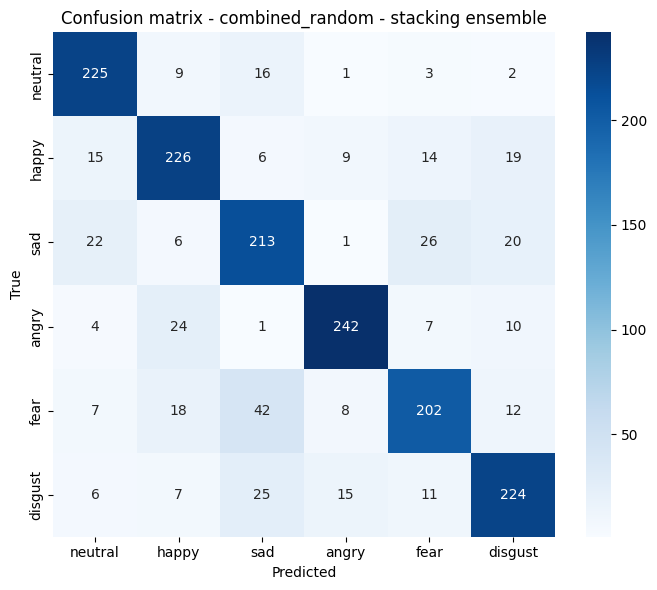

Finished: combined_random

RUN: combined_strict_no_tess {'train': 6110, 'validation': 854, 'test': 1953}
Using DataParallel for combined_strict_no_tess/temporal_bilstm_attention on 2 GPUs
combined_strict_no_tess | temporal_bilstm_attention | epoch 01 | train f1 0.2788 | val f1 0.2361
combined_strict_no_tess | temporal_bilstm_attention | epoch 02 | train f1 0.4010 | val f1 0.2966
combined_strict_no_tess | temporal_bilstm_attention | epoch 03 | train f1 0.4824 | val f1 0.3393
combined_strict_no_tess | temporal_bilstm_attention | epoch 04 | train f1 0.5608 | val f1 0.3363
combined_strict_no_tess | temporal_bilstm_attention | epoch 05 | train f1 0.6248 | val f1 0.3518
combined_strict_no_tess | temporal_bilstm_attention | epoch 06 | train f1 0.5972 | val f1 0.4144
combined_strict_no_tess | temporal_bilstm_attention | epoch 07 | train f1 0.6749 | val f1 0.4214
combined_strict_no_tess | temporal_bilstm_attention | epoch 08 | train f1 0.6792 | val f1 0.4212
combined_strict_no_tess | temporal_b

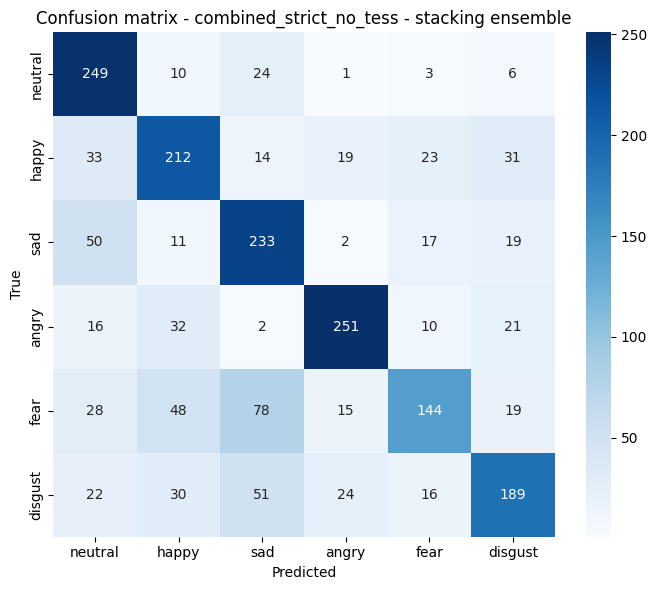

Finished: combined_strict_no_tess

RUN: single_CREMA-D {'train': 5208, 'validation': 1116, 'test': 1117}
Using DataParallel for single_CREMA-D/temporal_bilstm_attention on 2 GPUs
single_CREMA-D | temporal_bilstm_attention | epoch 01 | train f1 0.2669 | val f1 0.3037
single_CREMA-D | temporal_bilstm_attention | epoch 02 | train f1 0.3296 | val f1 0.4409
single_CREMA-D | temporal_bilstm_attention | epoch 03 | train f1 0.3540 | val f1 0.4022
single_CREMA-D | temporal_bilstm_attention | epoch 04 | train f1 0.4097 | val f1 0.4981
single_CREMA-D | temporal_bilstm_attention | epoch 05 | train f1 0.4406 | val f1 0.5165
single_CREMA-D | temporal_bilstm_attention | epoch 06 | train f1 0.4471 | val f1 0.5320
single_CREMA-D | temporal_bilstm_attention | epoch 07 | train f1 0.4724 | val f1 0.4764
single_CREMA-D | temporal_bilstm_attention | epoch 08 | train f1 0.4969 | val f1 0.5679
single_CREMA-D | temporal_bilstm_attention | epoch 09 | train f1 0.5207 | val f1 0.5358
single_CREMA-D | temporal_bil

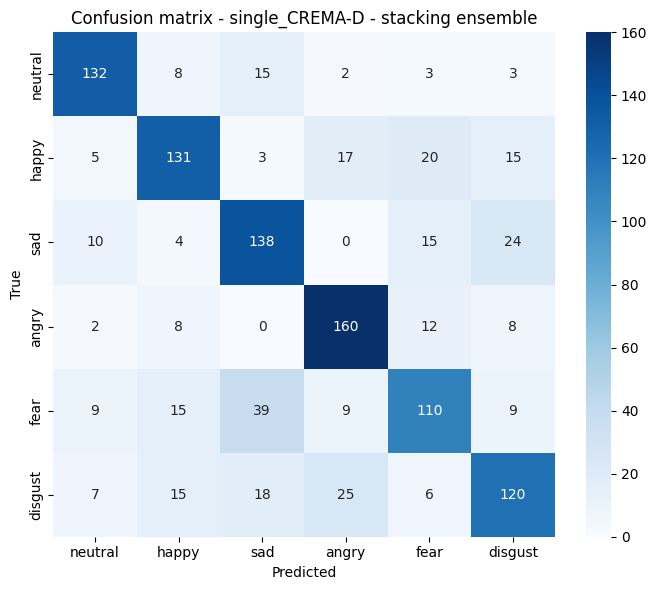

Finished: single_CREMA-D

RUN: single_RAVDESS {'train': 739, 'validation': 158, 'test': 159}
Using DataParallel for single_RAVDESS/temporal_bilstm_attention on 2 GPUs
single_RAVDESS | temporal_bilstm_attention | epoch 01 | train f1 0.1252 | val f1 0.1080
single_RAVDESS | temporal_bilstm_attention | epoch 02 | train f1 0.1815 | val f1 0.1234
single_RAVDESS | temporal_bilstm_attention | epoch 03 | train f1 0.1818 | val f1 0.1730
single_RAVDESS | temporal_bilstm_attention | epoch 04 | train f1 0.2179 | val f1 0.1804
single_RAVDESS | temporal_bilstm_attention | epoch 05 | train f1 0.2639 | val f1 0.2900
single_RAVDESS | temporal_bilstm_attention | epoch 06 | train f1 0.2821 | val f1 0.2163
single_RAVDESS | temporal_bilstm_attention | epoch 07 | train f1 0.3106 | val f1 0.3340
single_RAVDESS | temporal_bilstm_attention | epoch 08 | train f1 0.3576 | val f1 0.3933
single_RAVDESS | temporal_bilstm_attention | epoch 09 | train f1 0.3860 | val f1 0.4286
single_RAVDESS | temporal_bilstm_attentio

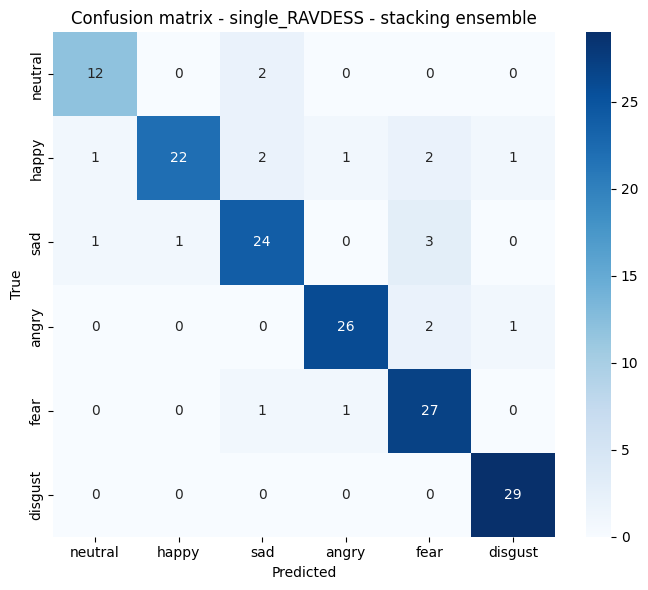

Finished: single_RAVDESS

RUN: single_SAVEE {'train': 294, 'validation': 63, 'test': 63}
Using DataParallel for single_SAVEE/temporal_bilstm_attention on 2 GPUs
single_SAVEE | temporal_bilstm_attention | epoch 01 | train f1 0.1748 | val f1 0.1761
single_SAVEE | temporal_bilstm_attention | epoch 02 | train f1 0.1563 | val f1 0.2994
single_SAVEE | temporal_bilstm_attention | epoch 03 | train f1 0.2513 | val f1 0.2201
single_SAVEE | temporal_bilstm_attention | epoch 04 | train f1 0.2868 | val f1 0.3111
single_SAVEE | temporal_bilstm_attention | epoch 05 | train f1 0.2958 | val f1 0.2001
single_SAVEE | temporal_bilstm_attention | epoch 06 | train f1 0.3194 | val f1 0.3325
single_SAVEE | temporal_bilstm_attention | epoch 07 | train f1 0.3406 | val f1 0.4283
single_SAVEE | temporal_bilstm_attention | epoch 08 | train f1 0.3476 | val f1 0.3896
single_SAVEE | temporal_bilstm_attention | epoch 09 | train f1 0.3596 | val f1 0.4601
single_SAVEE | temporal_bilstm_attention | epoch 10 | train f1 0.

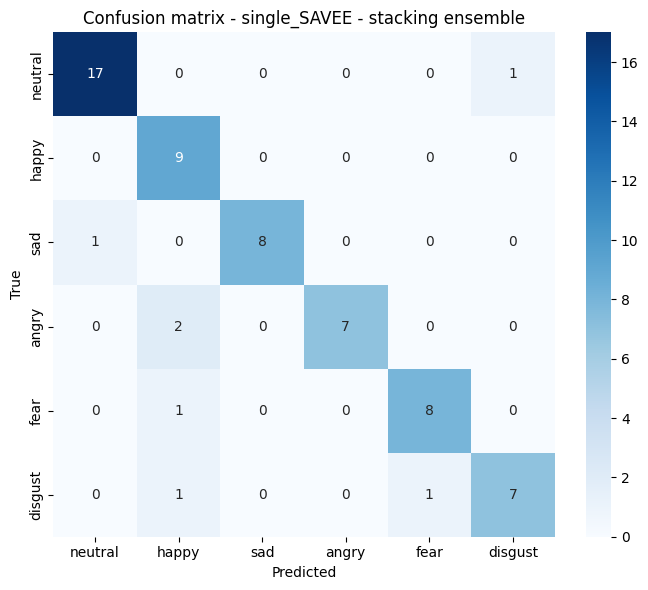

Finished: single_SAVEE

RUN: single_TESS {'train': 1680, 'validation': 360, 'test': 360}
Using DataParallel for single_TESS/temporal_bilstm_attention on 2 GPUs
single_TESS | temporal_bilstm_attention | epoch 01 | train f1 0.4604 | val f1 0.8705
single_TESS | temporal_bilstm_attention | epoch 02 | train f1 0.8328 | val f1 0.9833
single_TESS | temporal_bilstm_attention | epoch 03 | train f1 0.8773 | val f1 0.9944
single_TESS | temporal_bilstm_attention | epoch 04 | train f1 0.8578 | val f1 0.9945
single_TESS | temporal_bilstm_attention | epoch 05 | train f1 0.8379 | val f1 0.9972
single_TESS | temporal_bilstm_attention | epoch 06 | train f1 0.9287 | val f1 0.9888
single_TESS | temporal_bilstm_attention | epoch 07 | train f1 0.8365 | val f1 0.9972
single_TESS | temporal_bilstm_attention | epoch 08 | train f1 0.8705 | val f1 1.0000
single_TESS | temporal_bilstm_attention | epoch 09 | train f1 0.9775 | val f1 1.0000
single_TESS | temporal_bilstm_attention | epoch 10 | train f1 0.8712 | val 

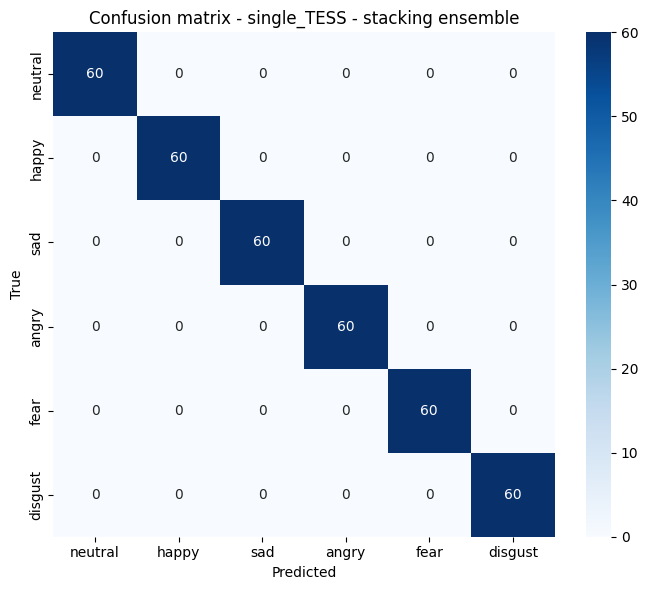

Finished: single_TESS


,run_name,model,split,n_samples,accuracy,macro_f1,weighted_f1,macro_precision,macro_recall,inference_time_sec,inference_ms_per_sample,best_epoch,best_val_macro_f1,train_time_sec
3,combined_random,stacking_logreg_ensemble,test,1698,0.784452,0.785293,0.784207,0.785682,0.786252,0.000868,0.000511,0,NaN,0.027820
1,combined_random,pretrained_speech_mlp,test,1698,0.754417,0.754671,0.753200,0.755621,0.756742,0.341336,0.201022,32,0.767017,85.120925
0,combined_random,temporal_bilstm_attention,test,1698,0.677856,0.677552,0.677359,0.682605,0.679318,0.656053,0.386368,22,0.675545,297.484354
2,combined_random,rich_stats_rbf_svm,test,1698,0.666667,0.666152,0.666493,0.667804,0.667686,5.077563,2.990320,0,0.673039,194.657214
7,combined_strict_no_tess,stacking_logreg_ensemble,test,1953,0.654378,0.650718,0.649320,0.661168,0.658204,0.001107,0.000567,0,NaN,0.041052
5,combined_strict_no_tess,pretrained_speech_mlp,test,1953,0.624680,0.625128,0.623691,0.630024,0.627752,0.405529,0.207644,16,0.666689,42.746426
6,combined_strict_no_tess,rich_stats_rbf_svm,test,1953,0.504352,0.504408,0.503572,0.505739,0.506506,5.688123,2.912505,0,0.491462,161.184978
4,combined_strict_no_tess,temporal_bilstm_attention,test,1953,0.474142,0.463824,0.463017,0.497807,0.480763,0.726110,0.371792,14,0.516208,164.484368
11,single_CREMA-D,stacking_logreg_ensemble,test,1117,0.708147,0.708548,0.706057,0.709310,0.710748,0.000709,0.000635,0,NaN,0.018858
9,single_CREMA-D,pretrained_speech_mlp,test,1117,0.686661,0.687432,0.684401,0.686635,0.690377,0.236660,0.211871,19,0.689314,43.308399


In [13]:
all_metrics = []
all_history = []
all_predictions = []
all_weights = []


def fit_stats_svm(run_name, split_map):
    train_idx, val_idx, test_idx = split_map["train"], split_map["validation"], split_map["test"]
    start = time.time()
    n_components = min(STATS_PCA_COMPONENTS, max(2, len(train_idx) - 1), X_stats.shape[1])
    model = make_pipeline(
        VarianceThreshold(),
        StandardScaler(),
        PCA(n_components=n_components, random_state=SEED),
        SVC(kernel="rbf", C=8.0, gamma="scale", probability=True, class_weight="balanced", random_state=SEED),
    )
    X_train_stats = X_stats[train_idx]
    y_train_stats = y[train_idx]
    if STATS_AUGMENT_TRAIN and X_stats_wave_aug is not None:
        aug_x = X_stats_wave_aug[:, train_idx, :].reshape(-1, X_stats.shape[1])
        aug_y = np.tile(y[train_idx], X_stats_wave_aug.shape[0])
        X_train_stats = np.vstack([X_train_stats, aug_x]).astype(np.float32)
        y_train_stats = np.concatenate([y_train_stats, aug_y]).astype(np.int64)
    model.fit(X_train_stats, y_train_stats)
    train_time = time.time() - start

    def predict(indices):
        t0 = time.time()
        prob = model.predict_proba(X_stats[indices])
        elapsed = time.time() - t0
        pred = prob.argmax(axis=1)
        yy = y[indices]
        return {
            "accuracy": accuracy_score(yy, pred),
            "macro_f1": f1_score(yy, pred, average="macro", zero_division=0),
            "weighted_f1": f1_score(yy, pred, average="weighted", zero_division=0),
            "macro_precision": precision_score(yy, pred, average="macro", zero_division=0),
            "macro_recall": recall_score(yy, pred, average="macro", zero_division=0),
            "y_true": yy,
            "y_pred": pred,
            "prob": prob,
            "elapsed_sec": elapsed,
        }

    val_res = predict(val_idx)
    test_res = predict(test_idx)
    return model, {"val": val_res, "test": test_res, "train_time_sec": train_time}


def run_protocol(run_name, split_map):
    print("\n" + "=" * 80)
    print("RUN:", run_name, {k: len(v) for k, v in split_map.items()})
    print("=" * 80)

    train_idx, val_idx, test_idx = split_map["train"], split_map["validation"], split_map["test"]
    scalers = compute_deep_scalers(train_idx)
    branch_val_probs = {}
    branch_test_probs = {}
    branch_names = []

    if RUN_TEMPORAL_BILSTM:
        temporal_train = TemporalDataset(train_idx, scalers, train=True)
        temporal_val = TemporalDataset(val_idx, scalers, train=False)
        temporal_test = TemporalDataset(test_idx, scalers, train=False)
        train_loader = make_loader(temporal_train, train_idx, train=True)
        val_loader = make_loader(temporal_val, val_idx, train=False)
        test_loader = make_loader(temporal_test, test_idx, train=False)

        model = TemporalBiLSTMAttention(TEMPORAL_DIM, len(COMMON_EMOTIONS))
        model, result = train_deep_model(
            run_name, "temporal_bilstm_attention",
            model, train_loader, val_loader, test_loader, train_idx,
            allow_mixup=True,
        )
        for row in result["history"]:
            all_history.append(row)
        r = metrics_row(run_name, "temporal_bilstm_attention", "test", result["test"], len(test_idx))
        r.update({"best_epoch": result["best_epoch"], "best_val_macro_f1": result["best_val_macro_f1"], "train_time_sec": result["train_time_sec"]})
        all_metrics.append(r)
        branch_val_probs["temporal_bilstm_attention"] = result["val"]["prob"]
        branch_test_probs["temporal_bilstm_attention"] = result["test"]["prob"]
        branch_names.append("temporal_bilstm_attention")

    if RUN_PRETRAINED_SPEECH and X_speech_embed is not None:
        speech_train = SpeechEmbeddingDataset(train_idx, scalers)
        speech_val = SpeechEmbeddingDataset(val_idx, scalers)
        speech_test = SpeechEmbeddingDataset(test_idx, scalers)
        train_loader = make_loader(speech_train, train_idx, train=True)
        val_loader = make_loader(speech_val, val_idx, train=False)
        test_loader = make_loader(speech_test, test_idx, train=False)

        model = SpeechEmbeddingMLP(X_speech_embed.shape[1], len(COMMON_EMOTIONS))
        model, result = train_deep_model(
            run_name, "pretrained_speech_mlp",
            model, train_loader, val_loader, test_loader, train_idx,
            allow_mixup=True,
        )
        for row in result["history"]:
            all_history.append(row)
        r = metrics_row(run_name, "pretrained_speech_mlp", "test", result["test"], len(test_idx))
        r.update({"best_epoch": result["best_epoch"], "best_val_macro_f1": result["best_val_macro_f1"], "train_time_sec": result["train_time_sec"]})
        all_metrics.append(r)
        branch_val_probs["pretrained_speech_mlp"] = result["val"]["prob"]
        branch_test_probs["pretrained_speech_mlp"] = result["test"]["prob"]
        branch_names.append("pretrained_speech_mlp")

    if RUN_STATS_SVM:
        model, result = fit_stats_svm(run_name, split_map)
        r = metrics_row(run_name, "rich_stats_rbf_svm", "test", result["test"], len(test_idx))
        r.update({"best_epoch": 0, "best_val_macro_f1": result["val"]["macro_f1"], "train_time_sec": result["train_time_sec"]})
        all_metrics.append(r)
        branch_val_probs["rich_stats_rbf_svm"] = result["val"]["prob"]
        branch_test_probs["rich_stats_rbf_svm"] = result["test"]["prob"]
        branch_names.append("rich_stats_rbf_svm")

    if RUN_STACKING and len(branch_names) >= 2:
        X_meta_val = np.concatenate([branch_val_probs[name] for name in branch_names], axis=1)
        X_meta_test = np.concatenate([branch_test_probs[name] for name in branch_names], axis=1)
        meta = LogisticRegression(max_iter=2000, C=0.8, class_weight="balanced", random_state=SEED)
        meta_start = time.time()
        meta.fit(X_meta_val, y[val_idx])
        train_time = time.time() - meta_start

        t0 = time.time()
        prob = meta.predict_proba(X_meta_test)
        infer_time = time.time() - t0
        pred = prob.argmax(axis=1)
        yy = y[test_idx]
        res = {
            "accuracy": accuracy_score(yy, pred),
            "macro_f1": f1_score(yy, pred, average="macro", zero_division=0),
            "weighted_f1": f1_score(yy, pred, average="weighted", zero_division=0),
            "macro_precision": precision_score(yy, pred, average="macro", zero_division=0),
            "macro_recall": recall_score(yy, pred, average="macro", zero_division=0),
            "y_true": yy,
            "y_pred": pred,
            "prob": prob,
            "elapsed_sec": infer_time,
        }
        r = metrics_row(run_name, "stacking_logreg_ensemble", "test", res, len(test_idx))
        r.update({"best_epoch": 0, "best_val_macro_f1": np.nan, "train_time_sec": train_time})
        all_metrics.append(r)

        pred_df = pd.DataFrame({
            "index": test_idx,
            "sample_id": metadata.loc[test_idx, "sample_id"].to_numpy(),
            "dataset": metadata.loc[test_idx, "dataset"].to_numpy(),
            "speaker_id": metadata.loc[test_idx, "speaker_id"].to_numpy(),
            "true_label": [ID_TO_LABEL[i] for i in yy],
            "pred_label": [ID_TO_LABEL[i] for i in pred],
        })
        for i, label in ID_TO_LABEL.items():
            pred_df[f"prob_{label}"] = prob[:, i]
        pred_df.to_csv(PRED_DIR / f"predictions_{run_name}_stacking_logreg_ensemble.csv", index=False)

        cm = confusion_matrix(yy, pred, labels=list(range(len(COMMON_EMOTIONS))))
        plt.figure(figsize=(7, 6))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=COMMON_EMOTIONS, yticklabels=COMMON_EMOTIONS)
        plt.title(f"Confusion matrix - {run_name} - stacking ensemble")
        plt.xlabel("Predicted")
        plt.ylabel("True")
        plt.tight_layout()
        plt.savefig(FIGURE_DIR / f"confusion_matrix_{run_name}_stacking.png", dpi=160)
        plt.show()

    print("Finished:", run_name)


for run_name, split_map in protocols:
    run_protocol(run_name, split_map)

metrics_df = pd.DataFrame(all_metrics)
history_df = pd.DataFrame(all_history)
metrics_df.to_csv(REPORT_DIR / "multi_presentation_update_metrics.csv", index=False)
history_df.to_csv(REPORT_DIR / "multi_presentation_update_history.csv", index=False)
display(metrics_df.sort_values(["run_name", "macro_f1"], ascending=[True, False]))


## 12. Visualize Results


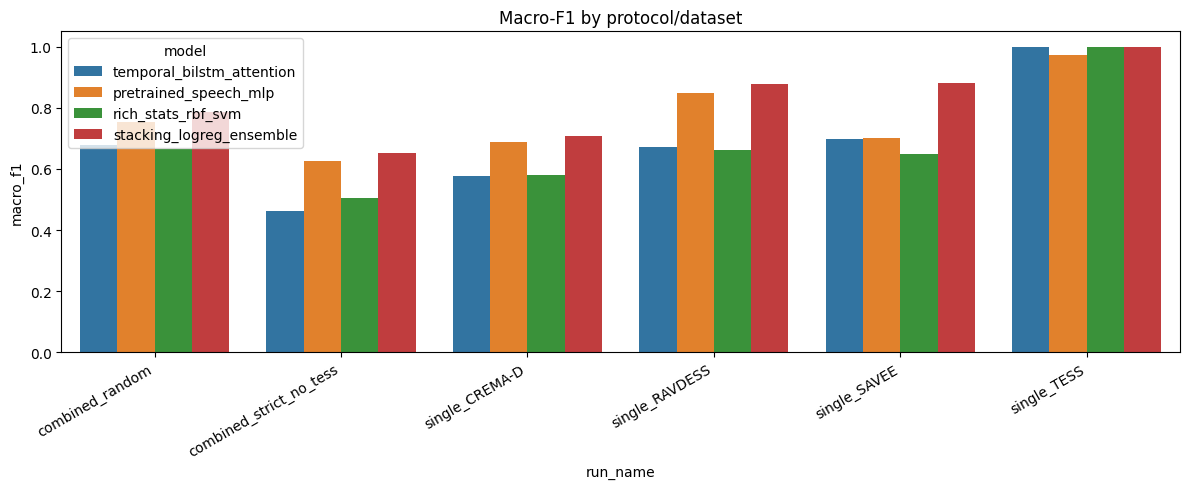

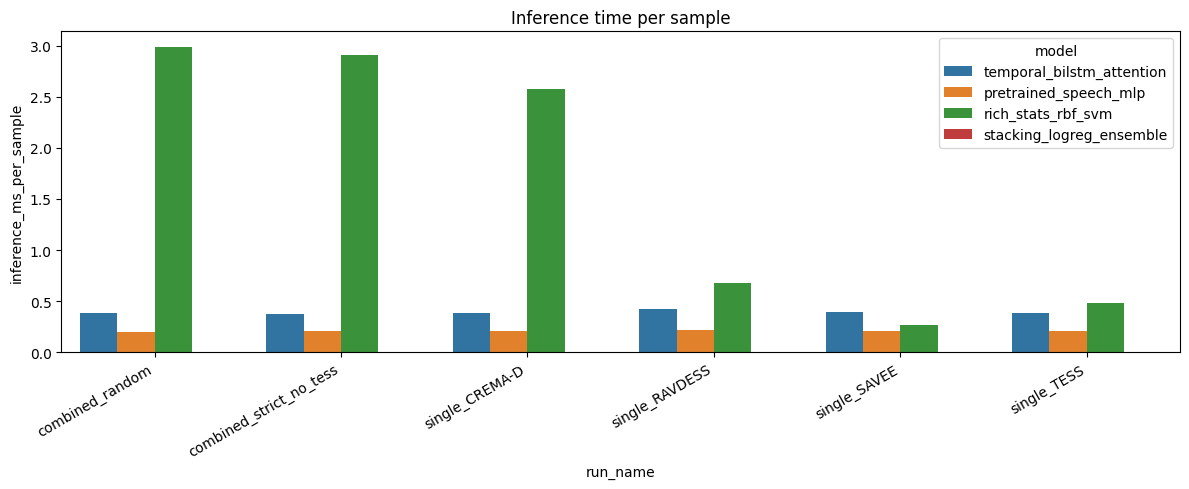

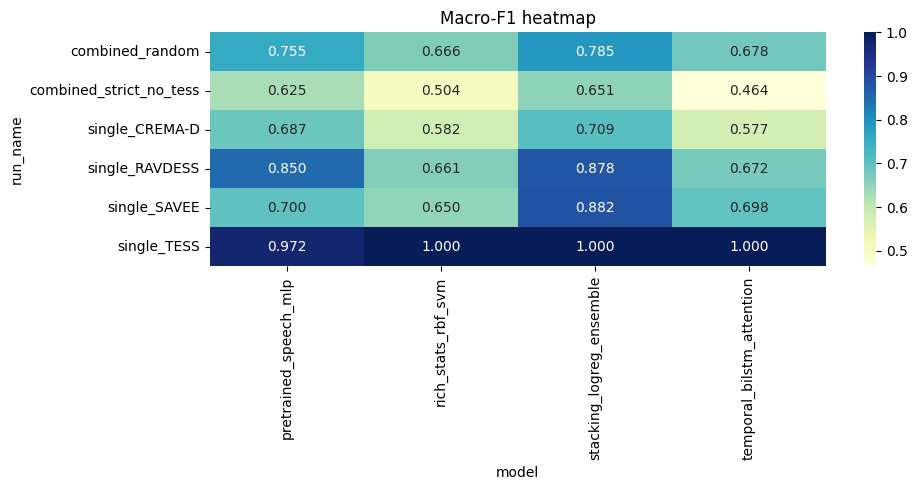

In [14]:
if len(metrics_df):
    plt.figure(figsize=(12, 5))
    sns.barplot(data=metrics_df, x="run_name", y="macro_f1", hue="model")
    plt.xticks(rotation=30, ha="right")
    plt.title("Macro-F1 by protocol/dataset")
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "multi_presentation_update_macro_f1.png", dpi=160)
    plt.show()

    plt.figure(figsize=(12, 5))
    sns.barplot(data=metrics_df, x="run_name", y="inference_ms_per_sample", hue="model")
    plt.xticks(rotation=30, ha="right")
    plt.title("Inference time per sample")
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "multi_presentation_update_inference_time.png", dpi=160)
    plt.show()

    pivot = metrics_df.pivot_table(index="run_name", columns="model", values="macro_f1", aggfunc="max")
    plt.figure(figsize=(10, 5))
    sns.heatmap(pivot, annot=True, fmt=".3f", cmap="YlGnBu")
    plt.title("Macro-F1 heatmap")
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "multi_presentation_update_macro_f1_heatmap.png", dpi=160)
    plt.show()


## 13. Compare with Previous 05 and Literature

Các bài reference chính thường báo accuracy cao nhưng không cùng strict speaker-aware protocol. Vì vậy bảng này dùng để đặt kết quả vào bối cảnh, không kết luận trực tiếp model nào tốt hơn nếu split khác nhau.


In [15]:
reference_rows = [
    {
        "model": "Ahmed et al. weighted ensemble 1D-CNN + CNN-LSTM + CNN-GRU",
        "protocol": "single-dataset, split not clearly strict speaker-aware",
        "reported_accuracy_text": "TESS 99.46%; RAVDESS 95.62%; SAVEE 93.22%; CREMA-D 90.47%",
        "main_idea": "Handcrafted features, augmentation, recurrent CNN variants, weighted ensemble.",
    },
    {
        "model": "Lee & Nadeem MFCC 1D-CNN with channel/spatial attention",
        "protocol": "single-dataset benchmark, split not clearly strict speaker-aware",
        "reported_accuracy_text": "SAVEE 97.49%; RAVDESS 99.23%; CREMA-D 89.31%; TESS 99.82%",
        "main_idea": "MFCC input, CNN feature extraction, attention reweighting.",
    },
    {
        "model": "Chowdhury et al. DCRF-BiLSTM feature engineering",
        "protocol": "individual and combined datasets, not clearly same as our strict split",
        "reported_accuracy_text": "RAVDESS 97.83%; SAVEE 97.02%; CREMA-D 95.10%; TESS 100%; R+T+S+E+C 93.76%",
        "main_idea": "Richer handcrafted acoustic features, augmentation, BiLSTM temporal modeling, DeepCRF.",
    },
]
reference_df = pd.DataFrame(reference_rows)
reference_df.to_csv(REPORT_DIR / "reference_model_literature_comparison.csv", index=False)
display(reference_df)

previous_paths = [
    Path("05_Main_Model/outputs/05_Multi_Representation_Ensemble_SER/reports/multi_rep_ensemble_metrics.csv"),
    Path.cwd() / "05_Main_Model/outputs/05_Multi_Representation_Ensemble_SER/reports/multi_rep_ensemble_metrics.csv",
]
previous_metrics = None
for p in previous_paths:
    if p.exists():
        previous_metrics = pd.read_csv(p)
        previous_metrics["source"] = "previous_multi_rep"
        break

current = metrics_df.copy()
current["source"] = "multi_presentation_update"
if previous_metrics is not None:
    keep_cols = ["source", "run_name", "model", "accuracy", "macro_f1", "inference_ms_per_sample"]
    comparison = pd.concat([previous_metrics[keep_cols], current[keep_cols]], ignore_index=True)
else:
    comparison = current[["source", "run_name", "model", "accuracy", "macro_f1", "inference_ms_per_sample"]]

comparison.to_csv(REPORT_DIR / "previous_vs_multi_presentation_update_comparison.csv", index=False)
display(comparison.sort_values(["run_name", "macro_f1"], ascending=[True, False]).head(40))


,model,protocol,reported_accuracy_text,main_idea
0,Ahmed et al. weighted ensemble 1D-CNN + CNN-LS...,"single-dataset, split not clearly strict speak...",TESS 99.46%; RAVDESS 95.62%; SAVEE 93.22%; CRE...,"Handcrafted features, augmentation, recurrent ..."
1,Lee & Nadeem MFCC 1D-CNN with channel/spatial ...,"single-dataset benchmark, split not clearly st...",SAVEE 97.49%; RAVDESS 99.23%; CREMA-D 89.31%; ...,"MFCC input, CNN feature extraction, attention ..."
2,Chowdhury et al. DCRF-BiLSTM feature engineering,"individual and combined datasets, not clearly ...",RAVDESS 97.83%; SAVEE 97.02%; CREMA-D 95.10%; ...,"Richer handcrafted acoustic features, augmenta..."


,source,run_name,model,accuracy,macro_f1,inference_ms_per_sample
3,multi_presentation_update,combined_random,stacking_logreg_ensemble,0.784452,0.785293,0.000511
1,multi_presentation_update,combined_random,pretrained_speech_mlp,0.754417,0.754671,0.201022
0,multi_presentation_update,combined_random,temporal_bilstm_attention,0.677856,0.677552,0.386368
2,multi_presentation_update,combined_random,rich_stats_rbf_svm,0.666667,0.666152,2.990320
7,multi_presentation_update,combined_strict_no_tess,stacking_logreg_ensemble,0.654378,0.650718,0.000567
5,multi_presentation_update,combined_strict_no_tess,pretrained_speech_mlp,0.624680,0.625128,0.207644
6,multi_presentation_update,combined_strict_no_tess,rich_stats_rbf_svm,0.504352,0.504408,2.912505
4,multi_presentation_update,combined_strict_no_tess,temporal_bilstm_attention,0.474142,0.463824,0.371792
11,multi_presentation_update,single_CREMA-D,stacking_logreg_ensemble,0.708147,0.708548,0.000635
9,multi_presentation_update,single_CREMA-D,pretrained_speech_mlp,0.686661,0.687432,0.211871


## 14. Suggested Next Ideas

Nếu bản update này vẫn chưa đẩy strict lên đủ cao, các hướng đáng thử tiếp:

1. **Domain-adversarial training**: thêm domain classifier dự đoán dataset, dùng gradient reversal để ép embedding khó nhận ra dataset nhưng vẫn nhận ra emotion.
2. **Leave-one-corpus-out evaluation**: train trên 3 dataset, test trên dataset còn lại để đo generalization thật.
3. **Realtime mode**: thay BiLSTM bằng causal/unidirectional LSTM hoặc temporal convolution nếu cần streaming từng đoạn nhỏ.
4. **Emotion2vec / WavLM embeddings**: thử pretrained speech/emotion representation khác, vẫn frozen backbone.
5. **Dataset-balanced curriculum**: train ban đầu cân bằng dataset, sau đó fine-tune nhẹ trên strict validation setting.


## 15. Package Outputs


In [16]:
summary = {
    "notebook": "05_Multi_Presentation_Update_SER",
    "architecture": "deep waveform augmentation + feature-level augmentation + richer stats + temporal BiLSTM attention + frozen pretrained speech embedding + stacking ensemble",
    "output_dir": str(OUTPUT_DIR),
    "metrics_csv": str(REPORT_DIR / "multi_presentation_update_metrics.csv"),
    "history_csv": str(REPORT_DIR / "multi_presentation_update_history.csv"),
    "pretrained_speech_model": PRETRAINED_SPEECH_MODEL if X_speech_embed is not None else None,
    "notes": "Compare strict, random and single-dataset protocols separately. Stacking is trained on validation probabilities only.",
}
with open(REPORT_DIR / "multi_presentation_update_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)

zip_base = PROJECT_ROOT / "05_Multi_Presentation_Update_outputs_package"
zip_path = shutil.make_archive(str(zip_base), "zip", OUTPUT_DIR)
print("OUTPUT ZIP:", zip_path)

try:
    from IPython.display import FileLink, display
    display(FileLink(str(zip_path)))
except Exception as e:
    print("Download link display failed:", e)


OUTPUT ZIP: /kaggle/working/05_Multi_Presentation_Update_outputs_package.zip


/kaggle/working/05_Multi_Presentation_Update_outputs_package.zip